# 01. Dataset Curation, Label Distribution & ESM-2 Embeddings

## 1. Problem Overview
Predicting the **subcellular localization** of a protein from its amino acid sequence is fundamental to understanding its biological function, interaction partners, and potential drug target viability. 

This project frames subcellular localization as a **multi-label classification** task across **11 major cellular compartments** defined in the DeepLoc 2.0 benchmark:
- *Membrane, Cytoplasm, Nucleus, Extracellular, Cell membrane, Mitochondrion, Plastid, Endoplasmic reticulum, Lysosome/Vacuole, Golgi apparatus, Peroxisome*.

Rather than relying on evolutionary Multiple Sequence Alignments (MSAs) or handcrafted physicochemical features, we leverage frozen representations from **ESM-2** (`esm2_t33_650M_UR50D`, a 650M-parameter protein language model).

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import protein_loc as pl

%matplotlib inline
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'

## 2. Load Curated Datasets

We load the Swiss-Prot development dataset with precomputed 1280-dimensional ESM-2 embeddings (mean pooling) and the independent Human Protein Atlas (HPA) test set.

In [3]:
train_df, X_mean, y_train = pl.load_subcellular_data('../data/df_train_loc_mean.csv')
_, X_max, _ = pl.load_subcellular_data('../data/df_train_loc_max.csv')
test_df, X_test, y_test = pl.load_subcellular_data('../data/df_test_loc_mean.csv', is_test=True)

print(f"Development set: {X_mean.shape[0]:,} proteins, {X_mean.shape[1]} embedding features")
print(f"Independent HPA test set: {X_test.shape[0]:,} proteins, {X_test.shape[1]} embedding features")
print(f"Label space: {len(pl.SUBCELLULAR_LOCATIONS)} target compartments")

Development set: 11,052 proteins, 1280 embedding features
Independent HPA test set: 1,716 proteins, 1280 embedding features
Label space: 11 target compartments


## 3. Label Distribution & Class Imbalance

Subcellular compartments display significant natural imbalance. For instance, `Membrane` and `Cytoplasm` are heavily populated, whereas `Peroxisome` and `Plastid` are comparatively rare.

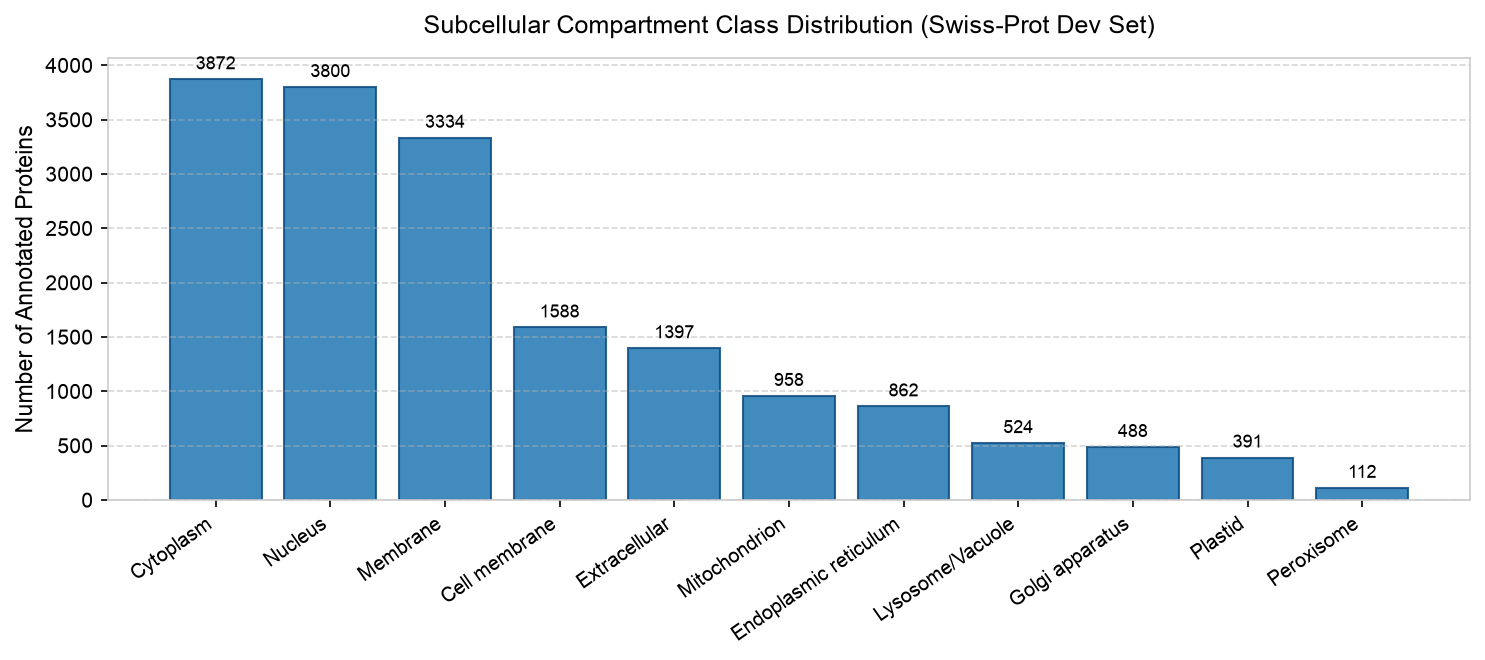

In [4]:
counts = pd.Series(y_train.sum(axis=0), index=pl.SUBCELLULAR_LOCATIONS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
bars = ax.bar(counts.index, counts.values, color='#1f77b4', edgecolor='#0f4c81', alpha=0.85)
ax.set_ylabel('Number of Annotated Proteins', fontsize=11)
ax.set_title('Subcellular Compartment Class Distribution (Swiss-Prot Dev Set)', fontsize=12, pad=12)
plt.xticks(rotation=35, ha='right', fontsize=9.5)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

## 4. Multi-Localization Cardinality

Many proteins localize to multiple cellular compartments simultaneously (e.g. shuttling between Nucleus and Cytoplasm). The multi-label nature of this problem is central to our evaluation.

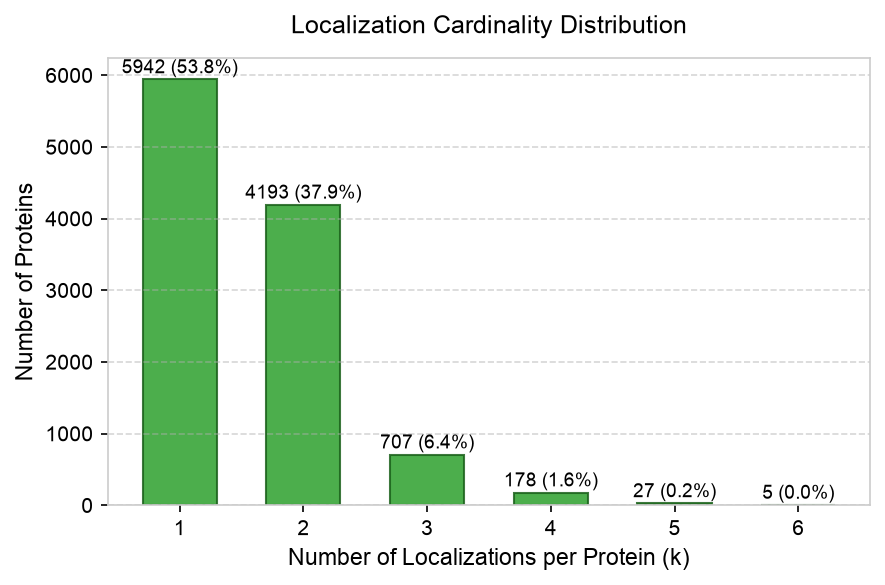

In [5]:
cardinality = y_train.sum(axis=1)
unique_k, counts_k = np.unique(cardinality, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.bar(unique_k, counts_k, color='#2ca02c', edgecolor='#1b611b', alpha=0.85, width=0.6)
ax.set_xlabel('Number of Localizations per Protein (k)', fontsize=11)
ax.set_ylabel('Number of Proteins', fontsize=11)
ax.set_title('Localization Cardinality Distribution', fontsize=12, pad=12)
ax.set_xticks(unique_k)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for x, y_val in zip(unique_k, counts_k):
    pct = (y_val / len(cardinality)) * 100
    ax.annotate(f'{y_val} ({pct:.1f}%)', (x, y_val), textcoords="offset points", xytext=(0, 3), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
# calculate the number of unique label combinations in the data
label_combos, combo_counts = np.unique(y_train, axis=0, return_counts=True)
combo_summary = pd.DataFrame({
    'label_combo': [tuple(row) for row in label_combos],
    'count': combo_counts,
}).sort_values('count', ascending=False)

print(f"Unique label combinations: {len(combo_summary)}")
print("Top 10 most common combinations:")
print(combo_summary.head(10).to_string(index=False))
print("\nBottom 10 rarest combinations:")
print(combo_summary.tail(10).to_string(index=False))


Unique label combinations: 154
Top 10 most common combinations:
                                            label_combo  count
(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)   2038
(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)   1719
(0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)   1406
(0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)   1206
(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)   1072
(0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0)    455
(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0)    418
(1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0)    307
(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0)    231
(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0)    199

Bottom 10 rarest combinations:
                                            label_combo  count
(1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0)      1
(0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0)      1
(0.0, 0.0, 0.0, 0.0, 1

Label support (positive counts):
Cytoplasm                3872
Nucleus                  3800
Membrane                 3334
Cell membrane            1588
Extracellular            1397
Mitochondrion             958
Endoplasmic reticulum     862
Lysosome/Vacuole          524
Golgi apparatus           488
Plastid                   391
Peroxisome                112


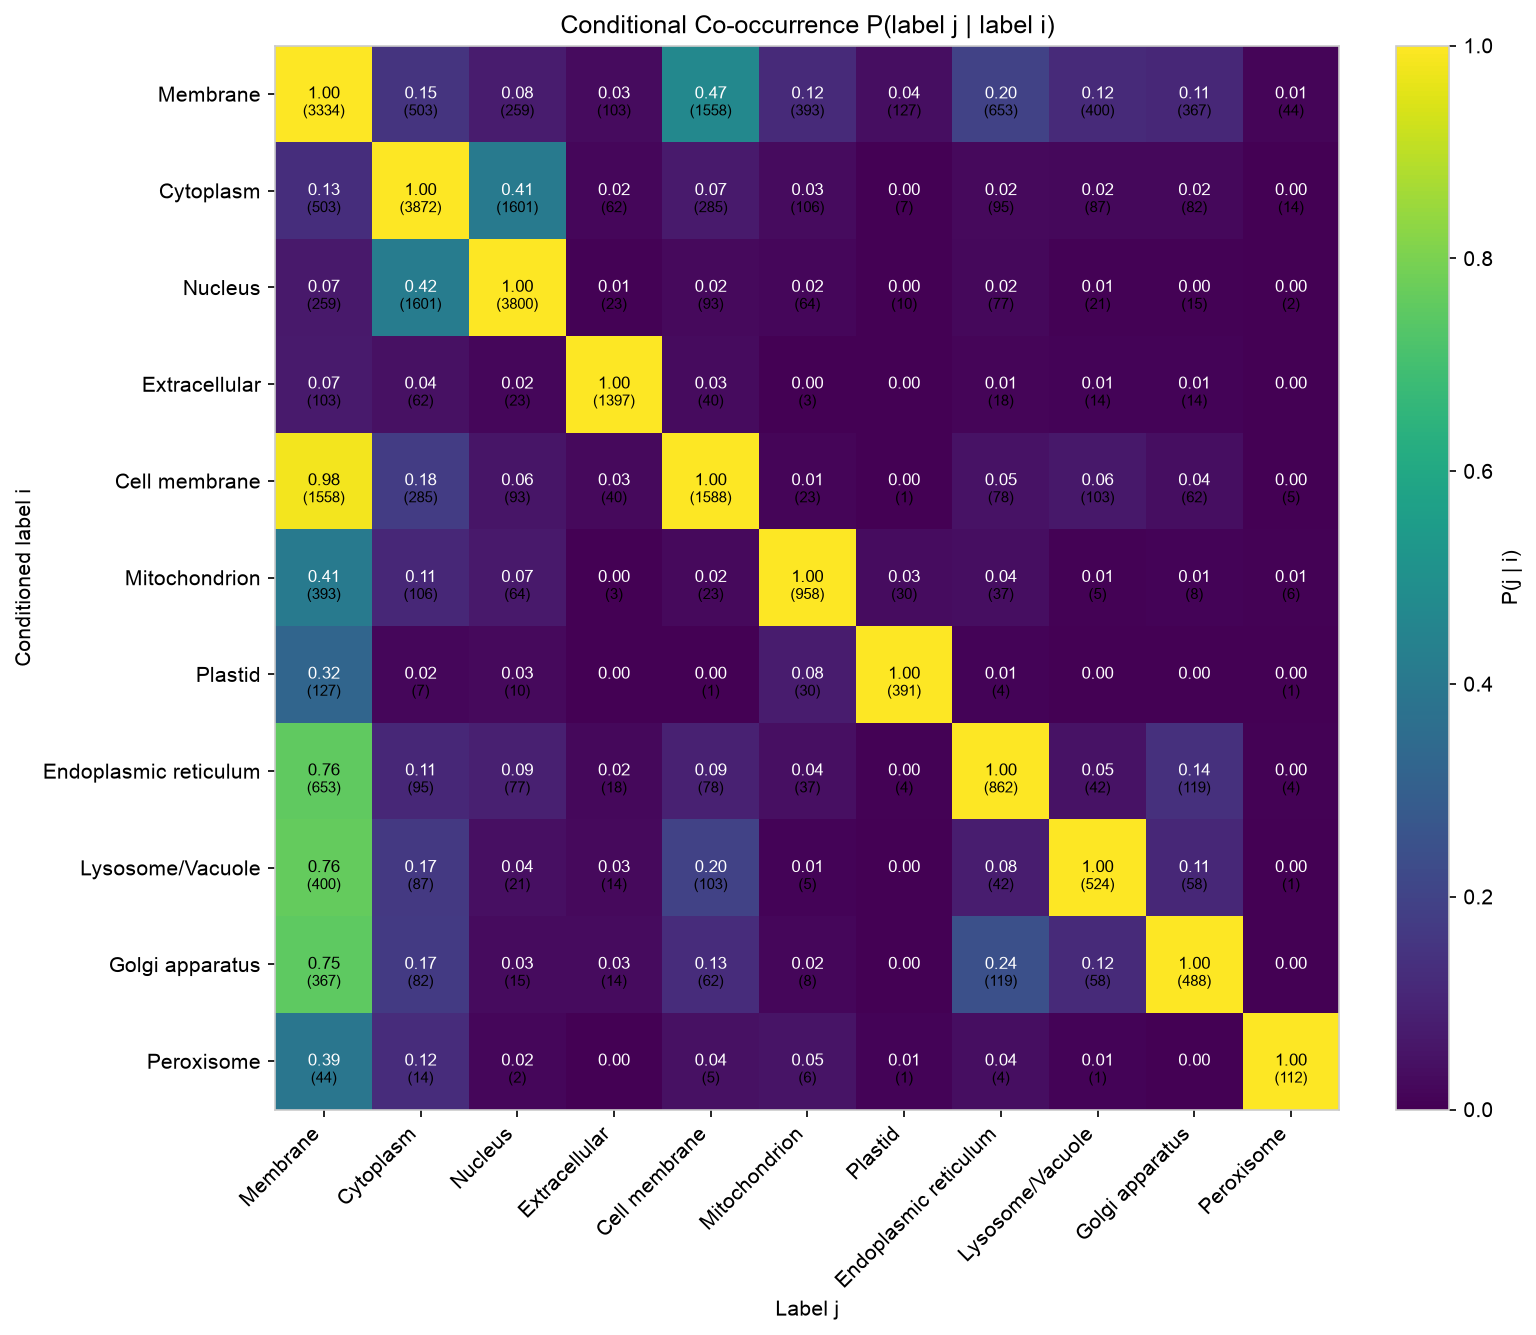


Conditional co-occurrence matrix:
                       Membrane  Cytoplasm  Nucleus  Extracellular  Cell membrane  Mitochondrion  Plastid  Endoplasmic reticulum  Lysosome/Vacuole  Golgi apparatus  Peroxisome
Membrane                  1.000      0.151    0.078          0.031          0.467          0.118    0.038                  0.196             0.120            0.110       0.013
Cytoplasm                 0.130      1.000    0.413          0.016          0.074          0.027    0.002                  0.025             0.022            0.021       0.004
Nucleus                   0.068      0.421    1.000          0.006          0.024          0.017    0.003                  0.020             0.006            0.004       0.001
Extracellular             0.074      0.044    0.016          1.000          0.029          0.002    0.000                  0.013             0.010            0.010       0.000
Cell membrane             0.981      0.179    0.059          0.025          1.000    

In [9]:
# Compute the 11x11 label co-occurrence matrix from the multi-label localization key.
Y = y_train.astype(int)
labels = pl.SUBCELLULAR_LOCATIONS
n_labels = len(labels)

# support[i] = total number of proteins annotated with label i
support = Y.sum(axis=0)

# raw_counts[i, j] = number of proteins with label i and j active together
raw_counts = Y.T @ Y

# conditional probability matrix: P(label j active | label i active)
cond_prob = np.full((n_labels, n_labels), np.nan, dtype=float)
nonzero_rows = support > 0
cond_prob[nonzero_rows, :] = np.divide(
    raw_counts[nonzero_rows, :],
    support[nonzero_rows, None],
    out=np.full((nonzero_rows.sum(), n_labels), np.nan, dtype=float),
    where=support[nonzero_rows, None] > 0,
)

# By definition, every label trivially co-occurs with itself.
np.fill_diagonal(cond_prob, 1.0)

# Handle labels with no positives explicitly.
zero_support = support == 0
if zero_support.any():
    print(f"Warning: labels with zero positive examples: {np.array(labels)[zero_support].tolist()}")

# Show a compact summary for the user.
print("Label support (positive counts):")
print(pd.Series(support, index=labels).sort_values(ascending=False).round(0).to_string())

# Plot the conditional co-occurrence heatmap.
fig, ax = plt.subplots(figsize=(11, 9), dpi=150)
heatmap = ax.imshow(cond_prob, cmap='viridis', vmin=0.0, vmax=1.0)

for i in range(n_labels):
    for j in range(n_labels):
        value = cond_prob[i, j]
        count = raw_counts[i, j]
        if np.isnan(value):
            txt = 'NA'
            text_color = 'white'
        else:
            txt = f'{value:.2f}'
            text_color = 'white' if value < 0.5 else 'black'
        ax.text(j, i, txt, ha='center', va='center', color=text_color, fontsize=8)
        if count > 0:
            ax.text(j, i + 0.18, f'({int(count)})', ha='center', va='center', color='black', fontsize=7)

ax.set_xticks(np.arange(n_labels))
ax.set_yticks(np.arange(n_labels))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
ax.set_title('Conditional Co-occurrence P(label j | label i)', fontsize=12)
ax.set_xlabel('Label j')
ax.set_ylabel('Conditioned label i')

for i in range(n_labels):
    for j in range(n_labels):
        if np.isnan(cond_prob[i, j]):
            ax.text(j, i, 'NA', ha='center', va='center', color='white', fontsize=8)

cbar = fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('P(j | i)', fontsize=10)
plt.tight_layout()
plt.show()

# Also expose the raw matrix and support for downstream analysis.
cooccurrence = pd.DataFrame(cond_prob, index=labels, columns=labels)
raw_counts_df = pd.DataFrame(raw_counts, index=labels, columns=labels)
print("\nConditional co-occurrence matrix:")
print(cooccurrence.round(3).to_string())
print("\nRaw co-occurrence counts:")
print(raw_counts_df.to_string())


## 5. ESM-2 Embeddings: Mean vs. Max Pooling Projections

We compute 2D Principal Component Analysis (PCA) and t-SNE projections of the 1280-dimensional embeddings to inspect latent spatial clustering.

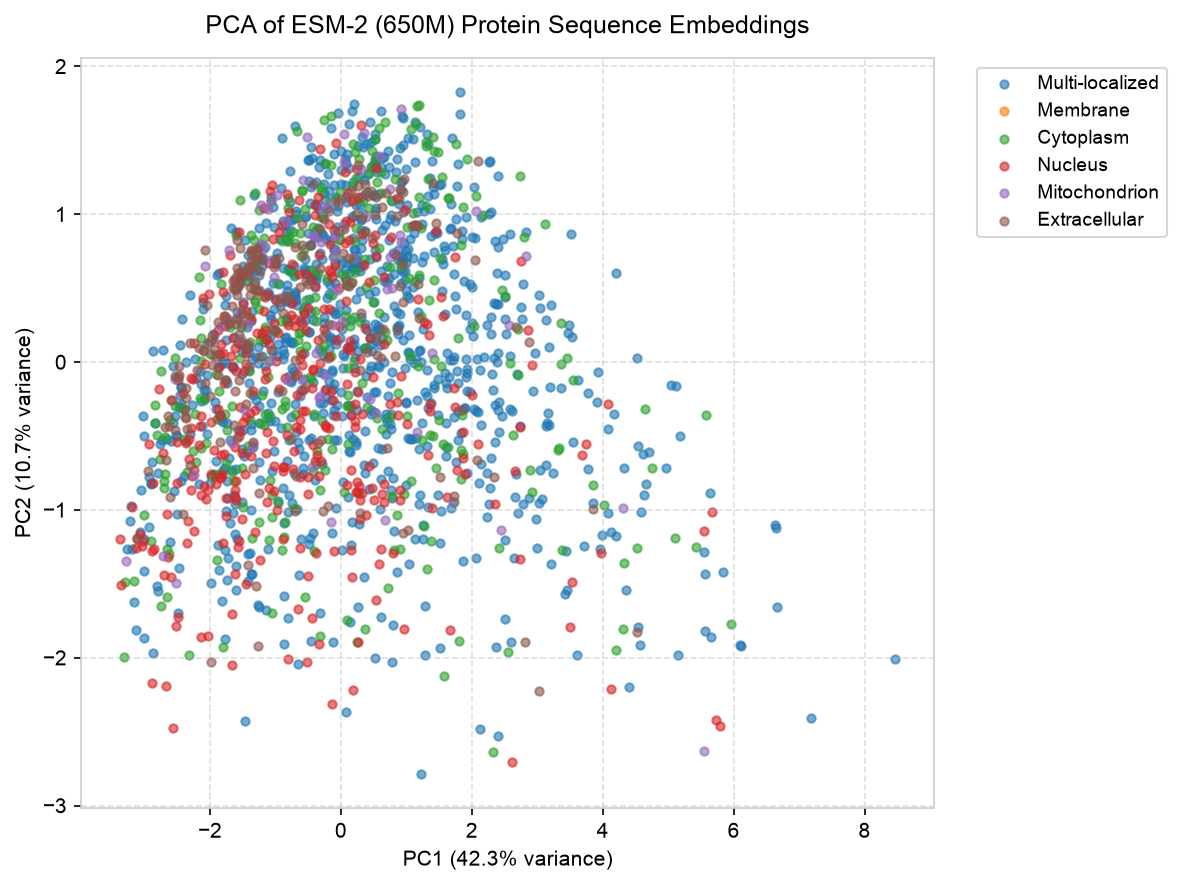

In [5]:
# Sample a subset for clean 2D visualization
np.random.seed(42)
sample_idx = np.random.choice(len(X_mean), size=2000, replace=False)
X_sample = X_mean[sample_idx]
y_sample = y_train[sample_idx]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

# Color by primary compartment (first positive class or Multi-localized)
primary_label = []
for row in y_sample:
    pos = np.where(row == 1)[0]
    if len(pos) == 0:
        primary_label.append('None')
    elif len(pos) > 1:
        primary_label.append('Multi-localized')
    else:
        primary_label.append(pl.SUBCELLULAR_LOCATIONS[pos[0]])

primary_series = pd.Series(primary_label)
top_classes = ['Multi-localized', 'Membrane', 'Cytoplasm', 'Nucleus', 'Mitochondrion', 'Extracellular']

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
for cls in top_classes:
    mask = (primary_series == cls).values
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, alpha=0.6, s=16)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
ax.set_title('PCA of ESM-2 (650M) Protein Sequence Embeddings', fontsize=12, pad=12)
ax.legend(bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()